# Lab 8: PCA

In this lab, we will examine how principal components can be used to discover low-dimensional structure in datasets. 

Useful command: 

- from sklearn.decomposition import PCA

## Reducing dimension

We will first demonstrate how PCA can be used to compute a useful low-dimensional projection of a high-dimensinal dataset. In some cases, this can help understand what a dataset looks like. Let us begin by loading the digits dataset that we used several times before. 

In [17]:
from sklearn.datasets import load_digits

# Load the digits dataset
digits = load_digits()

X = digits.data        # Flattened 8x8 images (n_samples, 64)
y = digits.target      # Labels 0-9

Let us compute the first 10 principal components of $X$.

In [18]:
from sklearn.decomposition import PCA
pc = PCA(n_components=10)
Xt = pc.fit_transform(X)

Let us plot the percentage of explained variance by the first $k$ components as a function of $k$:

Text(0, 0.5, 'Percantage of explained variance by k-th component')

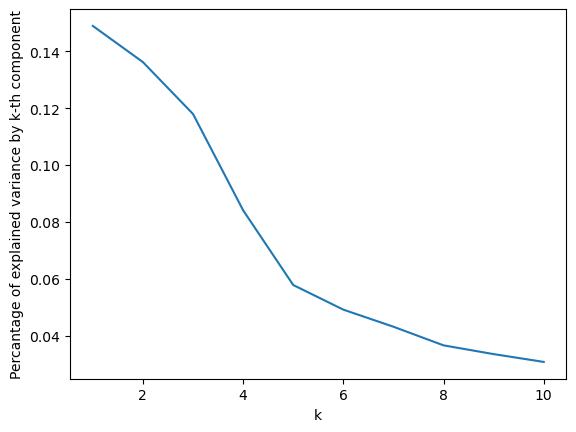

In [19]:
import matplotlib.pyplot as plt
plt.plot(range(1,11), pc.explained_variance_ratio_)
plt.xlabel("k")
plt.ylabel("Percantage of explained variance by k-th component")

Observe that the percentage of explained variance drops rapidely with the number of principal components. This is a very common behavior. Such a sharp drop suggests that only a few principal components suffice to represent the data well. 

To better visualize the percentage of explained variance, let us plot the cummulative sum of the percentages of explained variance.

Text(0, 0.5, 'Percantage of explained variance by first k-th components')

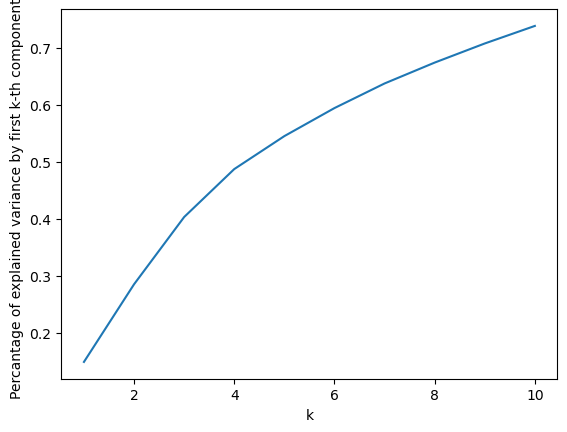

In [20]:
import numpy as np
plt.plot(range(1,11), np.cumsum(pc.explained_variance_ratio_))
plt.xlabel("k")
plt.ylabel("Percantage of explained variance by first k-th components")

Observe that the first 9 PCs already explain more than 70% of the variance of the dataset. 

Let us now project each image of a handwritten digit into the plane where the data has the most variance. We will use a color code to keep track of the labels of the images.

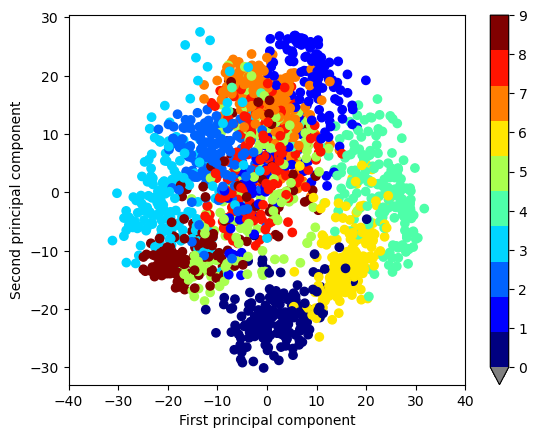

In [21]:
# Plot 2 dimensional projection

cmap = plt.get_cmap('jet', 10)
cmap.set_under('gray')

fig = plt.figure()
cax = plt.scatter(Xt[:,0], Xt[:,1], c=y, cmap=cmap, vmin=0, vmax=y.max())
fig.colorbar(cax, extend='min')
plt.xlim(-40,40)
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.show()

Notice how this 2-dimensional approximation of the data already shows a clear separation between the different digits! For example, the first two principal components do a very good job at separating the zero digits ("0") from the others. 

Recall that each image has 64 pixels and thus "lives" in a space with 64 dimensions. The above projection strongly suggests that if we could "see" the dataset in 64 dimensions, we would see clusters corresponding to each digit 0 to 9. 

**Exercise:** Repeat the above work with three principal components instead of two. Use the command *Axes3D* from *mpl_toolkits.mplot3d* to display a 3D projection of the dataset.

## Feature engineering

Recall that principal components are linear combinations of the original features, constructed to capture the variability in the data. In practice, they can be viewed as a form of *engineered features* that facilitate the exploration and visualization of datasets. Similarly, in fields like economics and engineering, composite indices are often used to summarize complex systems. For example, an engineer might combine multiple measurements of a road’s condition into a single score that determines whether or not maintenance is needed. Principal components serve a similar purpose: they combine features into summary variables, with the goal to capture as much of the total variance of the data as possible.

Principal components can also be directly used in further modeling steps. For example, recall the classical <a href="https://en.wikipedia.org/wiki/Iris_flower_data_set" target="_blank">Iris dataset</a> where the goal is to predict the type of Iris flower species using four measurements (the length and the width of the sepals and petals). Let us explore whether the first principal component is enough to summarize the four measurements and make an educated guess on the type of Iris. 

We begin by loading packages and the dataset.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Step 1: Load the Iris dataset
iris = load_iris()
X = iris.data          # shape (150, 4)
y = iris.target        # labels: 0=setosa, 1=versicolor, 2=virginica
target_names = iris.target_names


Next, let us compute the first two principal components and visualize them.

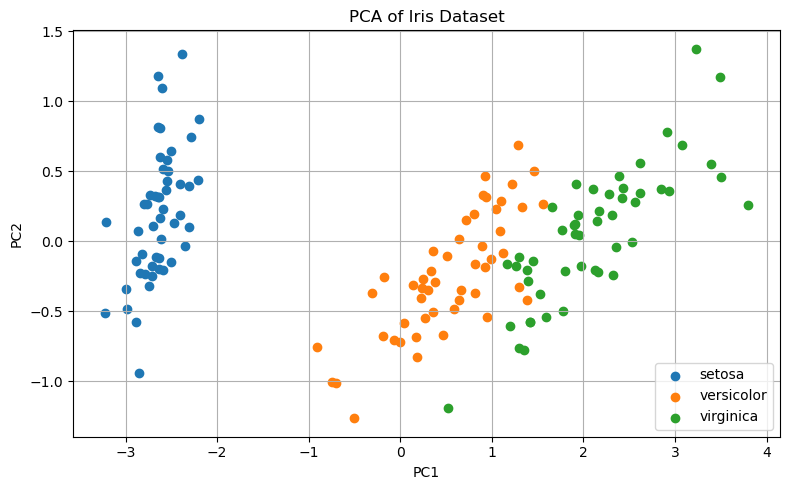

In [34]:
# Step 2: Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Visualize the first two principal components
plt.figure(figsize=(8, 5))
for i, target_name in enumerate(target_names):
    plt.scatter(X_pca[y == i, 0], X_pca[y == i, 1], label=target_name)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Iris Dataset')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

As in the digits example above, it seems like the first two PCs do a very good job at predicting the type of Iris. While not perfect, the first PC also seems to summarize the data very well. Let us examine the percentage of explained variance of the first two PCs: 

In [37]:
pca.explained_variance_ratio_

array([0.92461872, 0.05306648])

Indeed, the first PC already explains about 92% of the variance! It therefore summarizes the data very well. Let us try to use a logictic regression on the first PC to predict the labels. 

In [39]:
# Use only the first PC to predict the class
X_pc1 = X_pca[:, [0]]  # Use only PC1 as predictor

# Split into training/test sets
X_train, X_test, y_train, y_test = train_test_split(X_pc1, y, test_size=0.2, random_state=42)

# Train logistic regression
clf = LogisticRegression()
clf.fit(X_train, y_train)

# Predict and measure accuracy
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy using only PC1: {accuracy:.4f}")

Accuracy using only PC1: 0.9667


The accuracy is very good. For that particular problem, we can therefore reduce the four measurements to one new "feature" that captures the species of the Iris well. 

**Exercise:** We saw that the first principal component is an excellent indicator of the Iris species. Suppose someone in the field wants to use that information to identify Irises. Assume they measure the length and the width of the sepals and petals. Can you provide:

(1) The coefficients of the linear combination needed to compute the first principal component? 

(2) A simple test that can be computed by hand to approximately identify a new Iris (e.g., if the range of the first PC is between a1 and b1, then the iris is a *Versicolor*, if instead...)?